<a href="https://colab.research.google.com/github/Layomi-Ogungbe/IEUK-LLoyds-Banking-Group-Engineering-Skills-Project/blob/main/IEUK_LLoyds_Banking_Group_Engineering_Skills_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sample-log.log to sample-log.log


In [ ]:
import re
import pandas as pd

# Regular expression to parse log lines
log_pattern = re.compile(
    r'(?P<ip>\d+\.\d+\.\d+\.\d+)\s+-\s+(?P<user>\S+)\s+-\s+\[(?P<timestamp>[^\]]+)\]\s+'
    r'"(?P<method>\S+)\s(?P<path>\S+)\s(?P<protocol>[^"]+)"\s+'
    r'(?P<status>\d+)\s+(?P<size>\d+)\s+"(?P<referer>[^"]*)"\s+"(?P<agent>[^"]+)"\s+(?P<responsetime>\d+)'
)

# Read the log lines from file
parsed_data = []
with open("sample-log.log", 'r') as file:
    for line in file:
        match = log_pattern.match(line)
        if match:
            data = match.groupdict()
            parsed_data.append({
                "IP Address": data["ip"],
                "User": data["user"],
                "Timestamp": data["timestamp"],
                "Method": data["method"],
                "Path": data["path"],
                "Protocol": data["protocol"],
                "Status": int(data["status"]),
                "Size": int(data["size"]),
                "Referrer": data["referer"],
                "User-Agent": data["agent"],
                "Response Time": int(data["responsetime"]),
            })


# Create a DataFrame (table)
df = pd.DataFrame(parsed_data)
df.head()



,IP Address,User,Timestamp,Method,Path,Protocol,Status,Size,Referrer,User-Agent,Response Time
0,100.34.17.233,NO,01/07/2025:06:00:02,GET,/news/grammy-nominations-2024,HTTP/1.1,302,1234,-,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,269
1,173.80.18.254,NO,01/07/2025:06:00:04,POST,/,HTTP/1.1,200,1234,-,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,124
2,10.3.0.48,SE,01/07/2025:06:00:06,GET,/podcasts/behind-the-beat,HTTP/1.1,200,1234,-,Mozilla/5.0 (iPhone; CPU iPhone OS 17_2_1 like...,284
3,172.56.143.33,US,01/07/2025:06:00:08,GET,/terms-of-service,HTTP/1.1,200,1234,-,Mozilla/5.0 (iPhone; CPU iPhone OS 17_2_1 like...,262
4,208.54.157.184,NO,01/07/2025:06:00:09,POST,/privacy-policy,HTTP/1.1,200,1234,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,118


In [ ]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')
import plotly.graph_objs as go
import plotly.offline as py
from scipy import stats

In [ ]:
df.describe()

,Status,Size,Response Time
count,432096.000000,432096.0,432096.000000
mean,233.142674,1234.0,238.940458
std,75.454191,0.0,149.060629
min,200.000000,1234.0,10.000000
25%,200.000000,1234.0,118.000000
50%,200.000000,1234.0,224.000000
75%,200.000000,1234.0,330.000000
max,504.000000,1234.0,800.000000


In [ ]:
df.isnull().sum()

,0
IP Address,0
User,0
Timestamp,0
Method,0
Path,0
Protocol,0
Status,0
Size,0
Referrer,0
User-Agent,0


In [ ]:
df[df.duplicated(keep=False)]

,IP Address,User,Timestamp,Method,Path,Protocol,Status,Size,Referrer,User-Agent,Response Time


In [ ]:
for column in df.columns:
    num_distinct_values = df[column].nunique()
    print(f"Column '{column}' has {num_distinct_values} distinct values.")

Column 'IP Address' has 40887 distinct values.
Column 'User' has 14 distinct values.
Column 'Timestamp' has 207046 distinct values.
Column 'Method' has 7 distinct values.
Column 'Path' has 16270 distinct values.
Column 'Protocol' has 1 distinct values.
Column 'Status' has 12 distinct values.
Column 'Size' has 1 distinct values.
Column 'Referrer' has 1 distinct values.
Column 'User-Agent' has 25 distinct values.
Column 'Response Time' has 791 distinct values.


In [ ]:
cols_to_drop = [col for col in df.columns if df[col].nunique() == 1]
df.drop(columns=cols_to_drop)
display(df.head())

,IP Address,User,Timestamp,Method,Path,Protocol,Status,Size,Referrer,User-Agent,Response Time
0,100.34.17.233,NO,01/07/2025:06:00:02,GET,/news/grammy-nominations-2024,HTTP/1.1,302,1234,-,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,269
1,173.80.18.254,NO,01/07/2025:06:00:04,POST,/,HTTP/1.1,200,1234,-,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,124
2,10.3.0.48,SE,01/07/2025:06:00:06,GET,/podcasts/behind-the-beat,HTTP/1.1,200,1234,-,Mozilla/5.0 (iPhone; CPU iPhone OS 17_2_1 like...,284
3,172.56.143.33,US,01/07/2025:06:00:08,GET,/terms-of-service,HTTP/1.1,200,1234,-,Mozilla/5.0 (iPhone; CPU iPhone OS 17_2_1 like...,262
4,208.54.157.184,NO,01/07/2025:06:00:09,POST,/privacy-policy,HTTP/1.1,200,1234,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,118


In [ ]:
# List of common bot indicators in User-Agent
bot_keywords = ["bot", "crawler", "spider", "curl", "python", "wget", "scrapy", "scanner", "requests"]

# Define function to check if a row looks like bot traffic
def is_bot(row):
    user_agent = str(row["User-Agent"]).lower()
    response_time = row["Response Time"]

    return (
        any(keyword in user_agent for keyword in bot_keywords) or
        response_time < 50
    )

df["Suspicious"] = df.apply(is_bot, axis=1)

In [ ]:
df.head()

,IP Address,User,Timestamp,Method,Path,Protocol,Status,Size,Referrer,User-Agent,Response Time,Suspicious
0,100.34.17.233,NO,01/07/2025:06:00:02,GET,/news/grammy-nominations-2024,HTTP/1.1,302,1234,-,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,269,False
1,173.80.18.254,NO,01/07/2025:06:00:04,POST,/,HTTP/1.1,200,1234,-,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,124,False
2,10.3.0.48,SE,01/07/2025:06:00:06,GET,/podcasts/behind-the-beat,HTTP/1.1,200,1234,-,Mozilla/5.0 (iPhone; CPU iPhone OS 17_2_1 like...,284,False
3,172.56.143.33,US,01/07/2025:06:00:08,GET,/terms-of-service,HTTP/1.1,200,1234,-,Mozilla/5.0 (iPhone; CPU iPhone OS 17_2_1 like...,262,False
4,208.54.157.184,NO,01/07/2025:06:00:09,POST,/privacy-policy,HTTP/1.1,200,1234,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,118,False


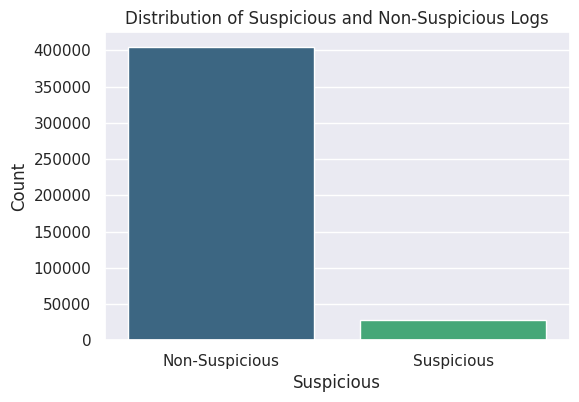

In [ ]:
suspicious_counts = df['Suspicious'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=suspicious_counts.index, y=suspicious_counts.values, hue=suspicious_counts.index, palette="viridis", legend=False)
plt.title("Distribution of Suspicious and Non-Suspicious Logs")
plt.xlabel("Suspicious")
plt.ylabel("Count")
plt.xticks([0, 1], ['Non-Suspicious', 'Suspicious'])
plt.show()

In [ ]:
suspicious_logs = df[df["Suspicious"] == True]
suspicious_logs.head()

,IP Address,User,Timestamp,Method,Path,Protocol,Status,Size,Referrer,User-Agent,Response Time,Suspicious
38,10.3.0.106,AU,01/07/2025:06:01:06,GET,/static/css/main.css,HTTP/1.1,200,1234,-,Mozilla/5.0 (Android 14; Mobile; rv:121.0) Gec...,44,True
68,52.84.128.86,NO,01/07/2025:06:02:06,GET,/favicon.ico,HTTP/1.1,200,1234,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,28,True
87,173.80.12.36,DE,01/07/2025:06:02:44,GET,/static/js/app.js,HTTP/1.1,200,1234,-,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,48,True
116,81.3.63.30,NO,01/07/2025:06:03:42,GET,/static/css/main.css,HTTP/1.1,404,1234,-,Mozilla/5.0 (iPad; CPU OS 17_2_1 like Mac OS X...,11,True
119,107.78.137.14,SE,01/07/2025:06:03:50,DELETE,/favicon.ico,HTTP/1.1,200,1234,-,Mozilla/5.0 (iPhone; CPU iPhone OS 17_2_1 like...,18,True


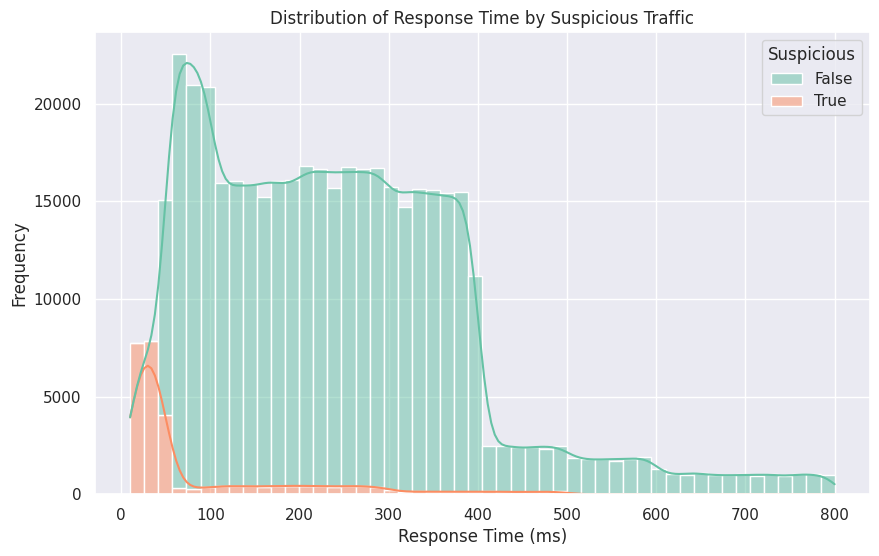

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Response Time", hue="Suspicious", bins=50, kde=True, palette="Set2", multiple="stack")
plt.title("Distribution of Response Time by Suspicious Traffic")
plt.xlabel("Response Time (ms)")
plt.ylabel("Frequency")
plt.show()


In [ ]:
suspicious_logs["Suspicious Time"] = suspicious_logs.apply(lambda row: row["Response Time"] < 50, axis=1)
suspicious_logs["Suspicious Agent"] = suspicious_logs.apply(lambda row: any(keyword in str(row["User-Agent"]).lower() for keyword in bot_keywords), axis=1)

/tmp/ipython-input-15-2543456151.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-15-2543456151.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
suspicious_ua = suspicious_logs[suspicious_logs["Suspicious Agent"] == True]
display(suspicious_ua.head())

,IP Address,User,Timestamp,Method,Path,Protocol,Status,Size,Referrer,User-Agent,Response Time,Suspicious,Suspicious Time,Suspicious Agent
99202,35.185.0.156,US,02/07/2025:05:00:00,GET,/search?year=2024,HTTP/1.1,200,1234,-,Wget/1.20.3 (linux-gnu),353,True,False,True
99203,35.185.0.156,US,02/07/2025:05:00:00,GET,/search,HTTP/1.1,200,1234,-,Wget/1.20.3 (linux-gnu),477,True,False,True
99204,35.185.0.156,US,02/07/2025:05:00:01,GET,/search,HTTP/1.1,200,1234,-,Wget/1.20.3 (linux-gnu),264,True,False,True
99205,35.185.0.156,US,02/07/2025:05:00:01,GET,/search?genre=ambient+soundscapes&s=The+1975&y...,HTTP/1.1,200,1234,-,Wget/1.20.3 (linux-gnu),446,True,False,True
99206,35.185.0.156,US,02/07/2025:05:00:02,GET,/search?s=Fontaines+D.C.&s=Arctic+Monkeys&dura...,HTTP/1.1,200,1234,-,Wget/1.20.3 (linux-gnu),477,True,False,True


In [ ]:
ip_avg_response = df.groupby("IP Address")["Response Time"].mean().sort_values(ascending=True)
ip_avg_response_df = ip_avg_response.reset_index().rename(columns={"Response Time": "Avg Response Time"})
ip_avg_response_df.head(10)



,IP Address,Avg Response Time
0,100.36.99.102,10.000000
1,68.2.19.58,22.000000
2,174.22.64.96,44.000000
3,108.49.4.51,50.333333
4,192.168.13.69,52.000000
5,173.161.73.103,53.500000
6,97.88.55.189,57.333333
7,71.234.115.164,58.000000
8,172.57.135.14,59.750000
9,174.49.222.179,62.000000


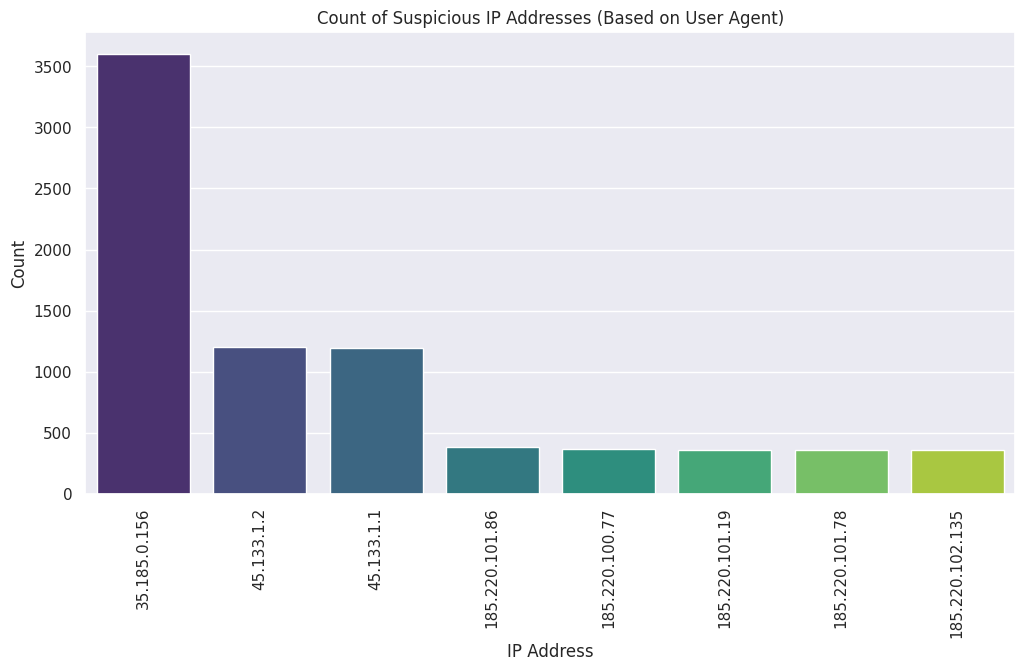

In [ ]:
suspicious_ip_counts = suspicious_ua["IP Address"].value_counts().head(20) # Display top 20 IPs
plt.figure(figsize=(12, 6))
sns.barplot(x=suspicious_ip_counts.index, y=suspicious_ip_counts.values, hue=suspicious_ip_counts.index, palette="viridis", legend=False)
plt.title("Count of Suspicious IP Addresses (Based on User Agent)")
plt.xlabel("IP Address")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [ ]:

print(suspicious_ua["User-Agent"].unique())


['Wget/1.20.3 (linux-gnu)' 'curl/7.68.0' 'python-requests/2.28.1']


In [ ]:
suspicious_ip_counts.head(10)

,count
IP Address,
35.185.0.156,3600
45.133.1.2,1199
45.133.1.1,1198
185.220.101.86,385
185.220.100.77,372
185.220.101.19,364
185.220.101.78,363
185.220.102.135,361


In [ ]:
import datetime
suspicious_logs['Parsed Time'] = pd.to_datetime(suspicious_logs['Timestamp'], format="%d/%m/%Y:%H:%M:%S")

suspicious_logs = suspicious_logs.sort_values(by=['IP Address', 'Parsed Time'])
suspicious_logs['Time Since Last'] = suspicious_logs.groupby('IP Address')['Parsed Time'].diff().dt.total_seconds()
suspicious_logs['Fast Request'] = suspicious_logs['Time Since Last'] < 2

suspicious_logs.head()

,IP Address,User,Timestamp,Method,Path,Protocol,Status,Size,Referrer,User-Agent,Response Time,Suspicious,Suspicious Time,Suspicious Agent,Parsed Time,Time Since Last,Fast Request
24420,10.0.0.105,SE,01/07/2025:11:50:39,GET,/static/css/main.css,HTTP/1.1,200,1234,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,20,True,True,False,2025-07-01 11:50:39,NaN,False
353179,10.0.0.105,CA,04/07/2025:12:10:12,GET,/static/css/main.css,HTTP/1.1,200,1234,-,Mozilla/5.0 (Android 14; Mobile; rv:121.0) Gec...,49,True,True,False,2025-07-04 12:10:12,260373.0,False
374620,10.0.0.105,SE,04/07/2025:15:00:39,GET,/static/css/main.css,HTTP/1.1,200,1234,-,Mozilla/5.0 (Android 14; Mobile; rv:121.0) Gec...,29,True,True,False,2025-07-04 15:00:39,10227.0,False
51437,10.0.0.116,UK,01/07/2025:15:13:00,GET,/static/css/main.css,HTTP/1.1,200,1234,-,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,10,True,True,False,2025-07-01 15:13:00,NaN,False
166152,10.0.0.137,NO,02/07/2025:15:37:47,GET,/static/js/app.js,HTTP/1.1,200,1234,-,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,27,True,True,False,2025-07-02 15:37:47,NaN,False


In [ ]:
fast_counts = suspicious_logs[suspicious_logs['Fast Request']].groupby('IP Address').size().reset_index(name='Fast Request Count')
fast_counts.head()

,IP Address,Fast Request Count
0,35.185.0.156,3599
1,45.133.1.1,239
2,45.133.1.2,243


In [ ]:
# Get total request count per IP
ip_request_counts = suspicious_logs['IP Address'].value_counts().reset_index()
ip_request_counts.columns = ['IP Address', 'Total Requests']

# Get active time range per IP
ip_time_range = suspicious_logs.groupby('IP Address')['Parsed Time'].agg(['min', 'max'])
ip_time_range['Active Duration (s)'] = (ip_time_range['max'] - ip_time_range['min']).dt.total_seconds()

# Combine and calculate frequency
ip_stats = ip_request_counts.merge(ip_time_range, on='IP Address')
ip_stats['Requests per Minute'] = ip_stats['Total Requests'] / (ip_stats['Active Duration (s)'] / 60)

# Flag IPs with high sustained frequency
ip_stats['Frequent Requester'] = ip_stats['Requests per Minute'] > 1
ip_stats.head(10)

,IP Address,Total Requests,min,max,Active Duration (s),Requests per Minute,Frequent Requester
0,35.185.0.156,3600,2025-07-02 05:00:00,2025-07-02 05:29:59,1799.0,120.066704,True
1,45.133.1.2,1199,2025-07-02 15:00:01,2025-07-02 15:59:57,3596.0,20.005562,True
2,45.133.1.1,1198,2025-07-02 15:00:04,2025-07-02 15:59:58,3594.0,20.000000,True
3,185.220.101.86,385,2025-07-04 19:00:40,2025-07-04 20:59:50,7150.0,3.230769,True
4,185.220.100.77,372,2025-07-04 19:00:09,2025-07-04 20:59:54,7185.0,3.106472,True
5,185.220.101.19,364,2025-07-04 19:00:27,2025-07-04 20:59:32,7145.0,3.056683,True
6,185.220.101.78,363,2025-07-04 19:01:03,2025-07-04 20:58:03,7020.0,3.102564,True
7,185.220.102.135,361,2025-07-04 19:00:01,2025-07-04 20:59:31,7170.0,3.020921,True
8,10.4.1.218,5,2025-07-03 06:34:27,2025-07-04 15:25:59,118292.0,0.002536,False
9,99.224.195.32,5,2025-07-04 08:57:58,2025-07-04 17:38:51,31253.0,0.009599,False
